# EDA analysis notebook

This notebook stands for EDA of 
[this dataset](https://www.kaggle.com/competitions/rossmann-store-sales/data?select=train.csv) (Rossmann Store Sales competition)

## Some notes about dataset

- sales data for 1,115 Rossmann stores
- Forecasting horizon is about 6 weeks (from competition requirements)
- Reliable sales forecasts enable store managers to create effective staff schedules that increase productivity and motivation
- Some stores in the dataset were temporarily closed for refurbishment.
- Note that all schools are closed on public holidays and weekends

## Prelimitary analysis

In [16]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv('/content/drive/MyDrive/data/store-sales-forecasting/train.csv')
df = df.set_index('Date')
df.index = pd.to_datetime(df.index)

/tmp/ipykernel_1571/592943605.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/data/store-sales-forecasting/train.csv')


In [3]:
df.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [4]:
df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


In [5]:
df.tail()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2013-01-01,1111,2,0,0,0,0,a,1
2013-01-01,1112,2,0,0,0,0,a,1
2013-01-01,1113,2,0,0,0,0,a,1
2013-01-01,1114,2,0,0,0,0,a,1
2013-01-01,1115,2,0,0,0,0,a,1


In [6]:
rows, columns = df.shape

print(f"Rows: {rows}\nColumns: {columns}")

Rows: 1017209
Columns: 8


In [7]:
print(f"total number of stores is {df["Store"].unique().sum()}")

total number of stores is 622170


In [8]:
df.isna().sum()

,0
Store,0
DayOfWeek,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [9]:
print(f'Duplicated rows: {df.index.duplicated().sum()} ({df.index.duplicated().sum() / rows*100:.2f}%)')

Duplicated rows: 1016267 (99.91%)


as we have multiple stores at 1 day (each row stands for day and store) we have many dublicates in dataset

## Feature preparation (basic)

Extract total sales, date, day of a week and e.c from the dataset

In [12]:
df["Total sales"] = df.groupby("Date")["Sales"].sum()

In [13]:
df[~df.index.duplicated()].head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Total sales
Date,,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1,10109742
2015-07-30,1,4,5020,546,1,1,0,1,8798854
2015-07-29,1,3,4782,523,1,1,0,1,8499962
2015-07-28,1,2,5011,560,1,1,0,1,9115073
2015-07-27,1,1,6102,612,1,1,0,1,10707292


In [18]:
df["Day of month"] = df.index.day
df["Month"] = df.index.month
df["Year"] = df.index.year
df["Week of year"] = df.index.isocalendar().week.astype(int)
df["Day of year"] = df.index.dayofyear
df["Quarter"] = df.index.quarter
df["Is weekend"] = (df.index.dayofweek >= 5).astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

df["Season"] = df["Month"].apply(get_season)

In [19]:
df.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Total sales', 'Day of month', 'Month',
       'Year', 'Week of year', 'Day of year', 'Quarter', 'Is weekend',
       'Season'],
      dtype='object')

In [20]:
df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Total sales,Day of month,Month,Year,Week of year,Day of year,Quarter,Is weekend,Season
Date,,,,,,,,,,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1,10109742,31,7,2015,31,212,3,0,2
2015-07-31,2,5,6064,625,1,1,0,1,10109742,31,7,2015,31,212,3,0,2
2015-07-31,3,5,8314,821,1,1,0,1,10109742,31,7,2015,31,212,3,0,2
2015-07-31,4,5,13995,1498,1,1,0,1,10109742,31,7,2015,31,212,3,0,2
2015-07-31,5,5,4822,559,1,1,0,1,10109742,31,7,2015,31,212,3,0,2


## Distribution analysis

Plot the distributions to meet my future work

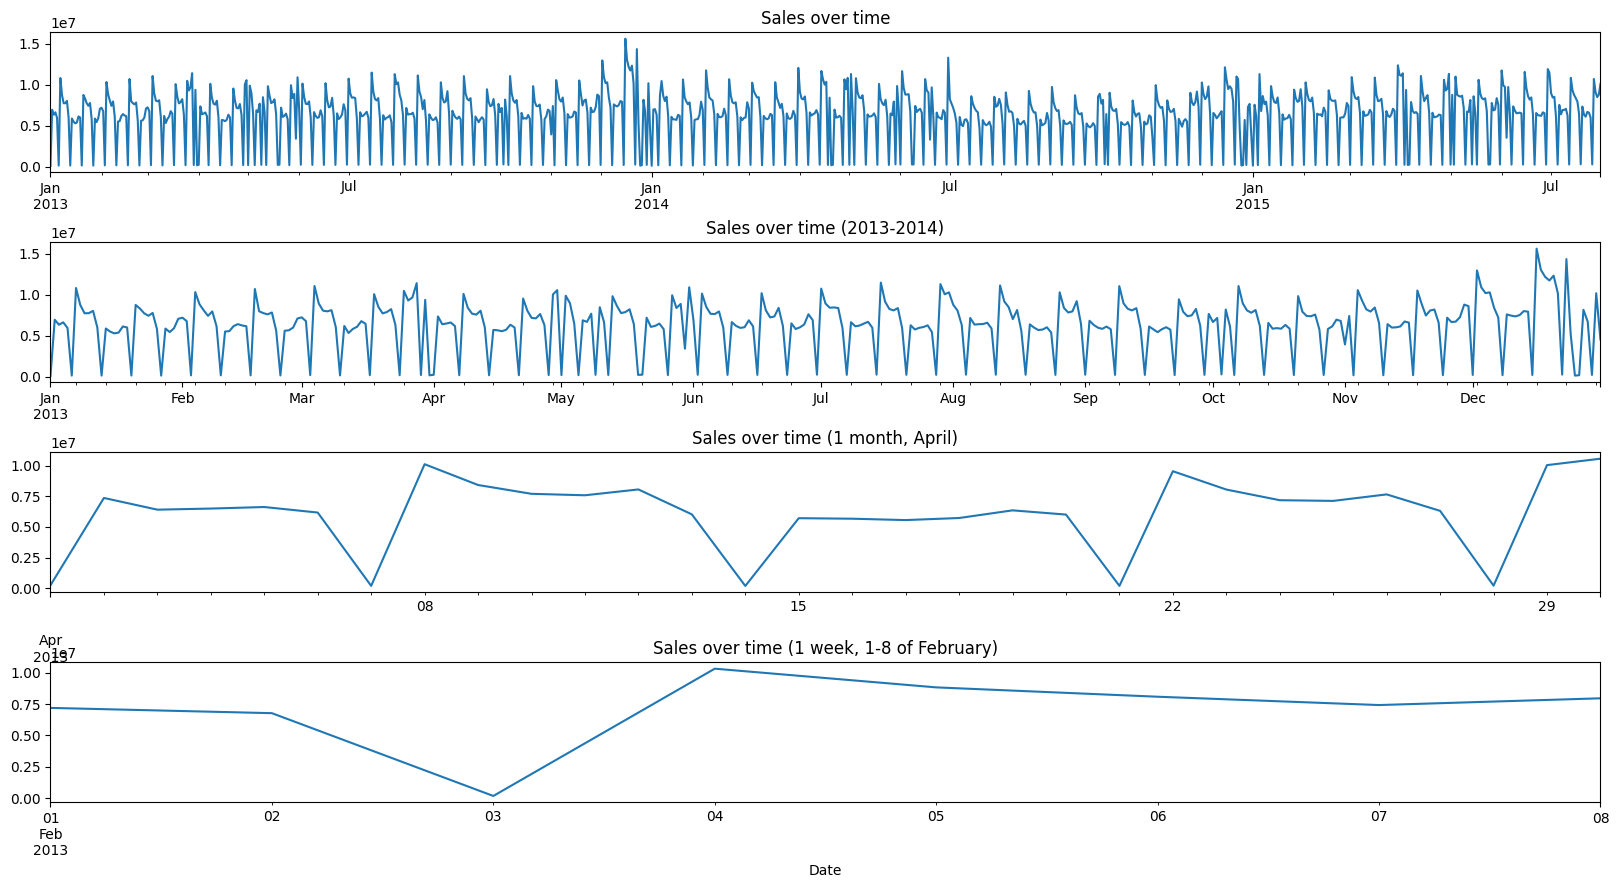

In [21]:
def clear_x_labels(ax):
    """Delete x labels except the last one
    Useful if plots shares same X label
    """
    for a in ax[:-1]:
        a.set_xlabel("")
    return ax

def plot_time_series_plots(nrows,ncolumns, df):
    fig, ax = plt.subplots(nrows,ncolumns, figsize=(20,10))
    fig.subplots_adjust(hspace=0.5)
    
    agg_df = df.groupby("Date")["Sales"].agg("sum")
    
    agg_df.plot(title="Sales over time", ax=ax[0])
    agg_df["2013-01-01" : "2013-12-31"].plot(title="Sales over time (2013-2014)", ax=ax[1])
    agg_df["2013-04-01" : "2013-04-30"].plot(title="Sales over time (1 month, April)", ax=ax[2])
    agg_df["2013-02-01" : "2013-02-8"].plot(title="Sales over time (1 week, 1-8 of February)", ax=ax[3])
    
    ax = clear_x_labels(ax)
    
plot_time_series_plots(4,1,df)
plt.show()

In [22]:
# TODO there is an outlier at january 2014
# TODO also there is similar otlier
# TODO: week plot is not similar to patterns

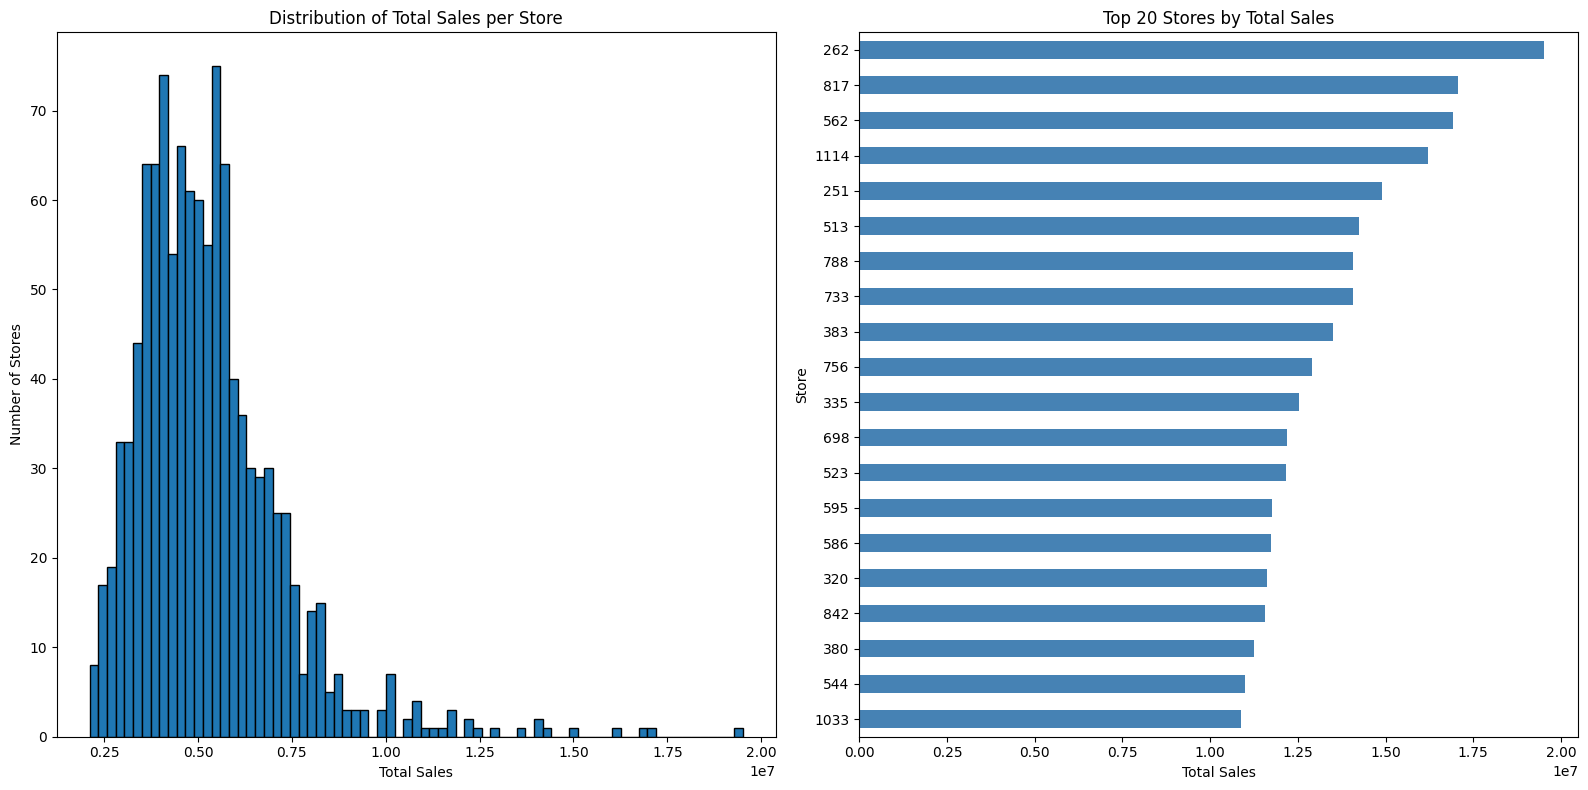

In [36]:
store_sales = df.groupby("Store")["Sales"].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

store_sales.plot(kind="hist", bins=75, ax=axes[0], edgecolor="black")
axes[0].set_title("Distribution of Total Sales per Store")
axes[0].set_xlabel("Total Sales")
axes[0].set_ylabel("Number of Stores")

top_n = 20
store_sales.tail(top_n).plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title(f"Top {top_n} Stores by Total Sales")
axes[1].set_xlabel("Total Sales")
axes[1].set_ylabel("Store")

plt.tight_layout()
plt.show()

In [ ]:
open_df = df[df["Open"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(open_df["Sales"], bins=60, edgecolor="black", alpha=0.7)
axes[0].set_title("Sales Distribution (Open Stores)")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Frequency")

axes[1].hist(open_df["Customers"], bins=60, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].set_title("Customers Distribution (Open Stores)")
axes[1].set_xlabel("Customers")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()